Loading the open-access Stable Diffusion model... This should take less than a minute!


model_index.json:   0%|          | 0.00/560 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--OFA-Sys--small-stable-diffusion-v0/snapshots/38e10e5e71e8fbf717a47a81e7543cd01c1a8140/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--OFA-Sys--small-stable-diffusion-v0/snapshots/38e10e5e71e8fbf717a47a81e7543cd01c1a8140/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion/pipeline_stable_diffusion.py:223: FutureWarning: The configuration file of this scheduler: DPMSolverMultistepScheduler {
  "_class_name": "DPMSolverMultistepScheduler",
  "_diffusers_version": "0.38.0",
  "algorithm_type": "dpmsolver++",
  "beta_end": 0.012,
  "beta_schedule": "scaled_linear",
  "beta_start": 0.00085,
  "dynamic_thresholding_ratio": 0.995,
  "euler_at_final": false,
  "final_sigmas_type": "zero",
  "flow_shift": 1.0,
  "lambda_min_clipped": -

Model loaded successfully onto the GPU without any authentication restrictions!
Generating image for prompt: 'A majestic astronaut riding a horse on Mars, highly detailed, sci-fi concept art'...


  0%|          | 0/50 [00:00<?, ?it/s]

Image saved as 'generated_output.png'!


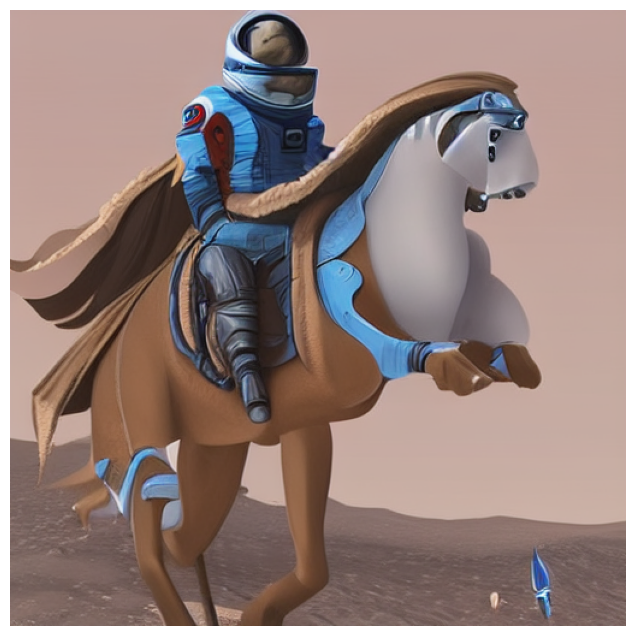

In [2]:
# 1. Install the required libraries for image generation
!pip install diffusers transformers accelerate torch

import torch
from diffusers import StableDiffusionPipeline
import matplotlib.pyplot as plt

# FIXED: Using a completely open, non-gated model repository to bypass the 401 error
model_id = "OFA-Sys/small-stable-diffusion-v0"

print("Loading the open-access Stable Diffusion model... This should take less than a minute!")
pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16)

# Move the model pipeline to the GPU for incredibly fast generation
pipe = pipe.to("cuda")
print("Model loaded successfully onto the GPU without any authentication restrictions!")

# 3. Define your creative text prompt
prompt = "A majestic astronaut riding a horse on Mars, highly detailed, sci-fi concept art"

# 4. Generate the image
print(f"Generating image for prompt: '{prompt}'...")
with torch.inference_mode():
    image = pipe(prompt).images[0]

# 5. Save the image to your Colab workspace
image.save("generated_output.png")
print("Image saved as 'generated_output.png'!")

# 6. Display the image directly in your notebook
plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.axis("off")
plt.show()